# PROYECTO: PREDICCIÓN DE ENFERMEDAD CARDÍACA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

## Diseño del problema y del modelo

El conjunto de datos seleccionado corresponde a pacientes evaluados para determinar la presencia de enfermedad cardíaca.  

El objetivo del proyecto es predecir si una persona presenta o no enfermedad cardíaca a partir de variables clínicas.

Este es un problema de **clasificación binaria**, porque la variable objetivo solo tiene dos clases:
- 0: ausencia de enfermedad cardíaca
- 1: presencia de enfermedad cardíaca

Las características de entrada corresponden a todas las variables del dataset excepto `target`, y se representan como `x`. 
La variable objetivo se representa como `y`.

Para el perceptrón se utilizará una función de activación **sigmoid** en la salida, ya que permite obtener una probabilidad entre 0 y 1. 
La función de pérdida asociada será **binary crossentropy**, adecuada para problemas de clasificación binaria.

### Carga de datos y preprocesamiento

In [2]:
df_heart=pd.read_csv('Data/heart.csv')

In [3]:
print(f"Forma de dataset: {df_heart.shape}")
df_heart.head()

Forma de dataset: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df_heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df_heart.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

### Identificar los valores nulos y eliminarlos

In [15]:
df_heart.isnull().sum()

age            0
sex            0
cp             0
trestbps       0
chol           0
fbs            0
restecg        0
thalach        0
exang          0
oldpeak        0
slope          0
ca             0
thal           0
target         0
cp_category    0
dtype: int64

No contamos contamos con valores nulos en el conjunto de datos, por lo que no es necesario realizar un proceso de limpieza para este tipo de valores.

### Declaracion de hiperparámetros y arquitectura de la red neuronal

In [28]:
y = df_heart['target'] # Variable objetivo (diagnóstico de enfermedad cardíaca)
x = df_heart.drop('target', axis=1) # Variables predictoras (excepto 'target')

## Análisis exploratorio de datos (EDA)

### Matriz de correlación entre las variables numéricas del dataset

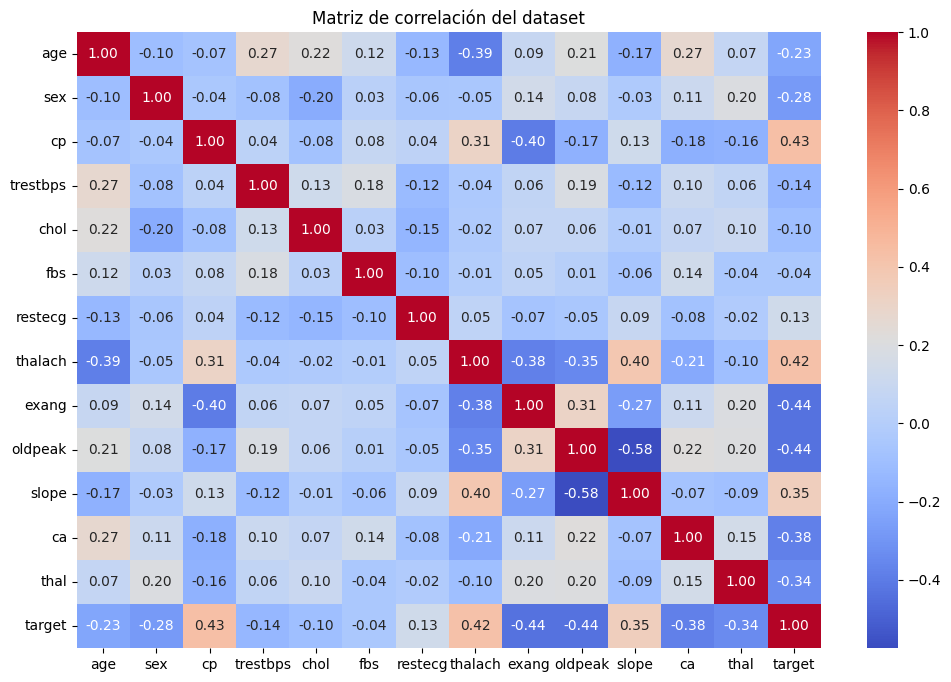

In [29]:
tabla = df_heart.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(tabla, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación del dataset')
plt.show()

Muestra la relación entre las variables numéricas del conjunto de datos. Se pueden identificar algunas correlaciones interesantes, como la relación entre 'thalach' (frecuencia cardíaca máxima) y 'target' (diagnóstico de enfermedad cardíaca), lo que sugiere que la frecuencia cardíaca máxima podría ser un factor importante para predecir la presencia de enfermedad cardíaca.

### Matriz de Correlación de Coeficiente de Pearson

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


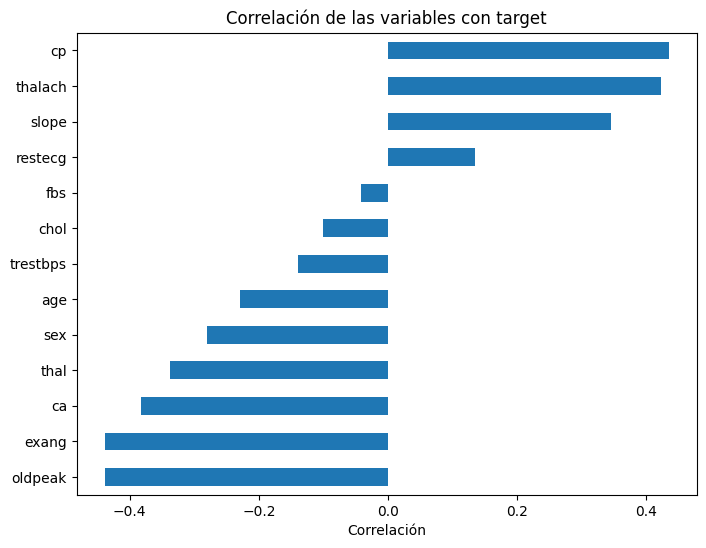

In [30]:
corr_target = df_heart.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(corr_target)

plt.figure(figsize=(8, 6))
corr_target.drop('target').sort_values().plot(kind='barh')
plt.title('Correlación de las variables con target')
plt.xlabel('Correlación')
plt.show()

Nos podemos dar cuenta que la variable 'thalach' (frecuencia cardíaca máxima) tiene una correlación positiva moderada con 'target' (diagnóstico de enfermedad cardíaca), lo que indica que a medida que aumenta la frecuencia cardíaca máxima, también aumenta la probabilidad de tener enfermedad cardíaca. Otras variables como 'cp' (tipo de dolor de pecho) y 'exang' (angina inducida por ejercicio) también muestran correlaciones positivas con 'target', lo que sugiere que podrían ser factores relevantes para predecir la presencia de enfermedad cardíaca.

1: Indica una correlación positiva perfecta.

0: Indica que no hay relación lineal.

-1: Indica una correlación negativa perfecta.

### Boxplot de thalach (frecuencia cardíaca máxima) según target (diagnóstico de enfermedad cardíaca)

C:\Users\JOSE\AppData\Local\Temp\ipykernel_26796\1730929730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='thalach', data=df_heart, palette='coolwarm')


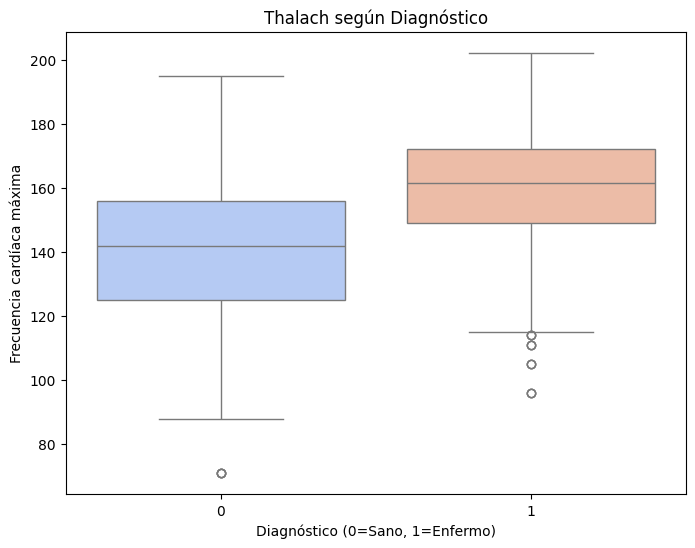

In [31]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='thalach', data=df_heart, palette='coolwarm')
plt.title("Thalach según Diagnóstico")
plt.xlabel("Diagnóstico (0=Sano, 1=Enfermo)")
plt.ylabel("Frecuencia cardíaca máxima")
plt.show()

Se puede observar que la variable thalach (frecuencia cardiaca máxima alcanzada) tiene una relacion opuesta con el diagnostico ya que a medida que aumenta la frecuencia cardiaca máxima alcanzada, la presencia de enfermedades del corazón disminuye.

### Histograma de age (edad) y  cantidad de personas

Text(0.5, 1.0, 'Cantidad de personas con ciertas edades')

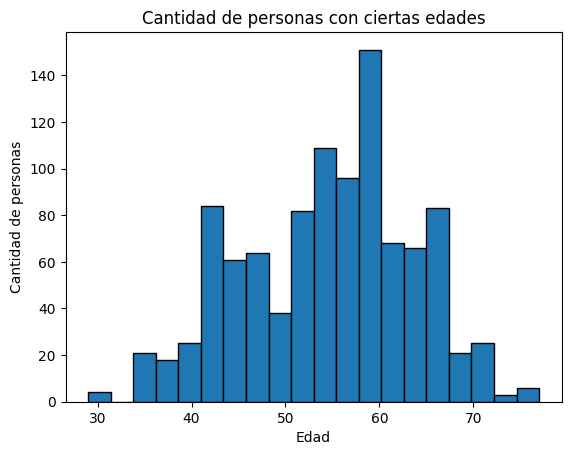

In [32]:
plt.hist(x['age'], edgecolor='black', bins=20)
plt.xlabel('Edad')
plt.ylabel('Cantidad de personas')
plt.title('Cantidad de personas con ciertas edades')

La cantidad de personas que mas tenemos en el dataset estan entre las edades dentro de los 55 a 60 años, lo que puede ser un factor de riesgo para las enfermedades del corazón.

### Violinplot de age (edad) según target (diagnóstico de enfermedad cardíaca)

<Axes: xlabel='target', ylabel='age'>

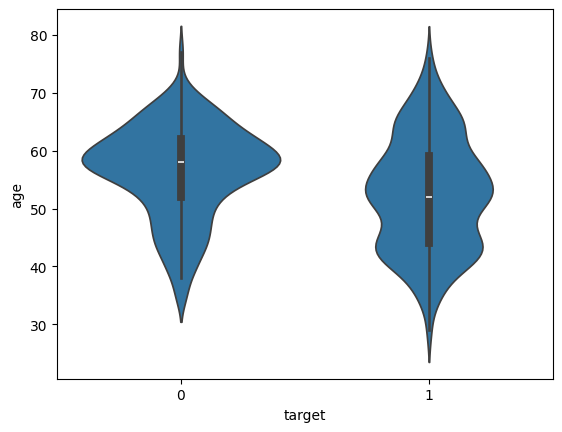

In [33]:
sns.violinplot(data=df_heart, x='target', y='age')

Segun lo que nos dice la grafica la edad no es un factor de riesgo para las enfermedades del corazón, ya que a medida que aumenta la edad no se muestra un aumento en la presencia de enfermedades del corazón porque si se mira la grafica nos dice el ancho es irrelavente de los dos violines no se ven afectados por la edad

### Countplot de cp (tipo de dolor de pecho, (0: típico, 1: atípico, 2: no anginal, 3: asintomático)) según target (diagnóstico de enfermedad cardíaca)

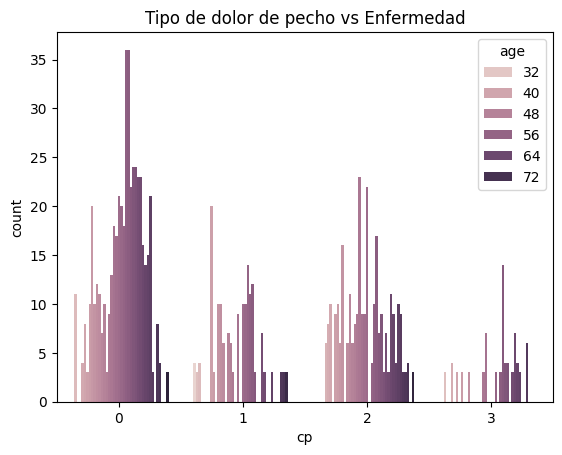

In [37]:
sns.countplot(x='cp', hue='age', data=df_heart)
plt.title("Tipo de dolor de pecho vs Enfermedad")
plt.show()

La grafica nos muestra que el tipo de dolor de pecho es un factor de riesgo para las enfermedades del corazón, ya que a medida que aumenta el tipo de dolor de pecho aumenta la presencia de enfermedades del corazón, ya que el tipo de dolor de pecho 0 (típico) es el que mas se relaciona con la presencia de enfermedades del corazón.

### Cross-tabulation entre target (diagnóstico de enfermedad cardíaca) y cp (tipo de dolor de pecho, (0: típico, 1: atípico, 2: no anginal, 3: asintomático))

<Axes: xlabel='target', ylabel='cp_category'>

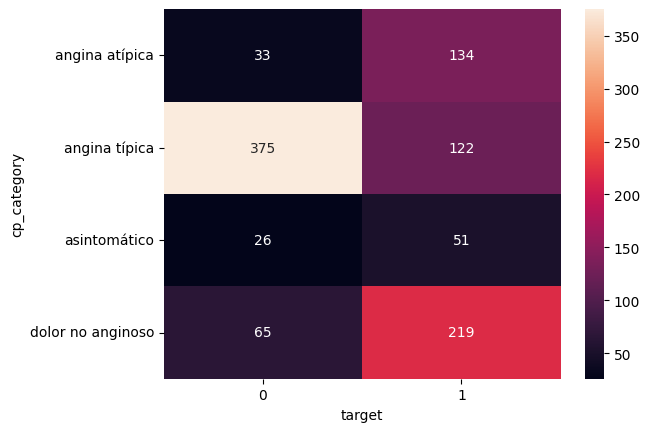

In [11]:
df_heart['cp_category']=df_heart['cp'].map(lambda x: "angina típica" if x == 0 else "angina atípica" if x == 1 else "dolor no anginoso" if x==2 else "asintomático")
tabla = pd.crosstab(df_heart['cp_category'], df_heart['target'])
sns.heatmap(tabla, annot=True, fmt='d')

Se puede observar claramente que las personsas con una angina tipica tiene una menor presencia de enfermedades del corazón, en cambio personans con un dolor no anginoso tiene una mayor presencia de enfermedades del corazón, lo que nos dice que el tipo de dolor en el pecho es un factor de riesgo para las enfermedades del corazón.  

### Conclusión del análisis exploratorio

El análisis exploratorio permitió identificar relaciones importantes entre las variables del dataset y la presencia de enfermedad cardíaca. 
Variables como el tipo de dolor de pecho, la edad y el colesterol muestran patrones diferenciados entre pacientes con y sin enfermedad. Esta información es útil para el entrenamiento del modelo de perceptrón, ya que permite entender mejor los datos de entrada.